# 10.3 XGBoost算法案例实战2 - 信用评分模型

In [2]:
import pandas as pd
df = pd.read_excel(r"D:\1Ftostudy\商业数据分析\@Python大数据分析与机器学习商业案例实战\@Python大数据分析与机器学习商业案例实战\第10章 机器学习神器：XGBoost&LightGBM模型\源代码汇总_Jupyer Notebook\信用评分卡模型.xlsx")
df.head()

,月收入,年龄,性别,历史授信额度,历史违约次数,信用评分
0,7783,29,0,32274,3,73
1,7836,40,1,6681,4,72
2,6398,25,0,26038,2,74
3,6483,23,1,24584,4,65
4,5167,23,1,6710,3,73


In [13]:
# 2. 提取特征变量和目标变量
X = df.drop(columns='信用评分')
y = df['信用评分']

In [17]:
# 3. 划分训练集和测试集
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)


## 随机森林回归模型

In [20]:
#模型搭建
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=123)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=123)

In [25]:
#模型预测及评估
# 模型预测
y_pred_rf = rf_model.predict(X_test)

# 模型评估
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"随机森林模型 R-squared: {r2_rf:.4f}")
print(f"随机森林模型 MSE: {mse_rf:.4f}")
print(f"随机森林模型 MAE: {mae_rf:.4f}")
print(f"随机森林模型 Score: {rf_model.score(X_test, y_test):.4f}")

# 预测值与实际值对比
rf_comparison = pd.DataFrame({'预测值': y_pred_rf, '实际值': y_test.values})
print("\n随机森林模型预测值与实际值对比:")
print(rf_comparison.head(10))

# 查看特征重要性
rf_importance_df = pd.DataFrame({
    '特征名称': X.columns,
    '特征重要性': rf_model.feature_importances_
}).sort_values('特征重要性', ascending=False)

print("\n随机森林模型特征重要性:")
print(rf_importance_df)

随机森林模型 R-squared: 0.6808
随机森林模型 MSE: 19.4165
随机森林模型 MAE: 3.6270
随机森林模型 Score: 0.6808

随机森林模型预测值与实际值对比:
     预测值  实际值
0  68.94   79
1  70.33   80
2  74.01   62
3  84.73   89
4  71.46   80
5  84.95   86
6  74.37   72
7  83.20   85
8  83.49   85
9  83.87   87

随机森林模型特征重要性:
     特征名称     特征重要性
0     月收入  0.414820
3  历史授信额度  0.270905
4  历史违约次数  0.207646
1      年龄  0.095011
2      性别  0.011618


## 支持向量机回归模型

In [28]:
#模型搭建
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# 对数据进行标准化（SVM对特征尺度敏感）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_model.fit(X_train_scaled, y_train)

SVR()

In [30]:
#模型预测及评估
# 模型预测
y_pred_svr = svr_model.predict(X_test_scaled)

# 模型评估
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
r2_svr = r2_score(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)

print(f"支持向量机回归模型 R-squared: {r2_svr:.4f}")
print(f"支持向量机回归模型 MSE: {mse_svr:.4f}")
print(f"支持向量机回归模型 MAE: {mae_svr:.4f}")

# 预测值与实际值对比
svr_comparison = pd.DataFrame({'预测值': y_pred_svr, '实际值': y_test.values})
print("\n支持向量机回归模型预测值与实际值对比:")
print(svr_comparison.head(10))

支持向量机回归模型 R-squared: 0.7080
支持向量机回归模型 MSE: 17.7631
支持向量机回归模型 MAE: 3.4805

支持向量机回归模型预测值与实际值对比:
         预测值  实际值
0  69.445342   79
1  74.261322   80
2  73.682286   62
3  85.180599   89
4  70.244795   80
5  85.763314   86
6  74.098896   72
7  84.975849   85
8  82.461311   85
9  84.265323   87


## 决策树回归模型

In [35]:
#模型搭建
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(max_depth=5, random_state=123)
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=123)

决策树回归模型 R-squared: 0.6058
决策树回归模型 MSE: 23.9782
决策树回归模型 MAE: 3.8310
决策树回归模型 Score: 0.6058

决策树回归模型预测值与实际值对比:
         预测值  实际值
0  68.000000   79
1  63.750000   80
2  76.666667   62
3  84.784394   89
4  69.216216   80
5  84.784394   86
6  73.111111   72
7  84.784394   85
8  84.784394   85
9  84.784394   87

决策树回归模型特征重要性:
     特征名称     特征重要性
0     月收入  0.708530
4  历史违约次数  0.207174
3  历史授信额度  0.056285
1      年龄  0.023616
2      性别  0.004395


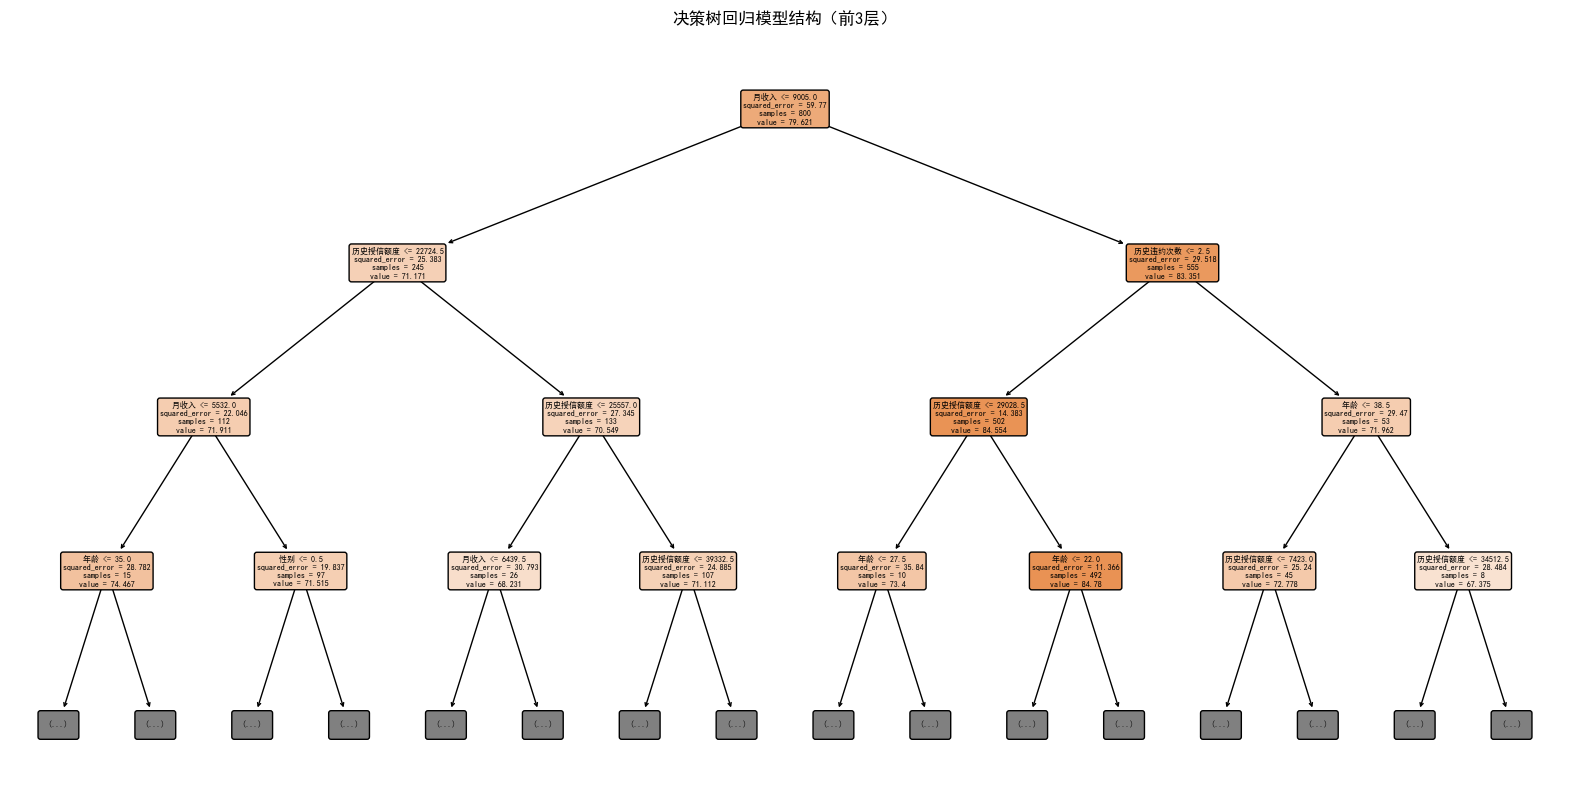

In [39]:
#模型预测及评估
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 模型预测
y_pred_dt = dt_model.predict(X_test)

# 模型评估
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
r2_dt = r2_score(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)

print(f"决策树回归模型 R-squared: {r2_dt:.4f}")
print(f"决策树回归模型 MSE: {mse_dt:.4f}")
print(f"决策树回归模型 MAE: {mae_dt:.4f}")
print(f"决策树回归模型 Score: {dt_model.score(X_test, y_test):.4f}")

# 预测值与实际值对比
dt_comparison = pd.DataFrame({'预测值': y_pred_dt, '实际值': y_test.values})
print("\n决策树回归模型预测值与实际值对比:")
print(dt_comparison.head(10))

# 查看特征重要性
dt_importance_df = pd.DataFrame({
    '特征名称': X.columns,
    '特征重要性': dt_model.feature_importances_
}).sort_values('特征重要性', ascending=False)

print("\n决策树回归模型特征重要性:")
print(dt_importance_df)

# 可视化决策树（可选）
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(dt_model, 
          feature_names=X.columns,
          filled=True, 
          rounded=True,
          max_depth=3)  # 只显示前3层以免过于复杂
plt.title('决策树回归模型结构（前3层）')
plt.show()